# Ramsey

This notebook shows you how to perform a Ramsey experiment. You'll sweep the delay between two slightly detuned pi/2 pulses to determine the qubit dephasing time as well as fine tune the calibration of the qubit excited state frequency.

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Helpers:
from laboneq.analysis.fitting import oscillatory_decay
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 6

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 11:09:35.873] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 11:09:35.874] INFO    VERSION: laboneq 26.4.0
[2026.06.26 11:09:35.875] INFO    Connecting to data server at localhost:8004
[2026.06.26 11:09:35.876] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 11:09:35.877] INFO    Configuring the device setup
[2026.06.26 11:09:35.903] INFO    The device setup is configured


## 2. Experiment Parameters

Now you'll define the amplitude sweep parameters and pulses to use in your experiment.

In [4]:
# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4

# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_ramsey_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )


# define delay sweep
n_steps = 201
start_delay = 0e-6
stop_delay = 15e-6


def create_delay_sweep(
    start=start_delay, stop=stop_delay, count=n_steps, axis_name="Time [s]"
):
    time_sweep = LinearSweepParameter(
        uid="time_sweep_param", start=start, stop=stop, count=count, axis_name=axis_name
    )
    return time_sweep

## 3. Experiment Definition

You'll now create a function which generates an [experiment](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/index.html). In this experiment, you'll pass a sweep parameter which changes delay time between two pulses as an argument to the [sweep section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/04_averaging_sweeping.html#parameter-sweeps). Within the sweeep section, you'll create another [section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/index.html) containing your drive pulses with `play` commands separated by a delay.

As the length of the Ramsey sweep section containing the drive pulses changes, using a right-aligned sweep section and the automatic repetition time makes sure that the experiment is run as efficiently as possible on the Zurich Instruments hardware.  

You'll also make a readout section containing `play` and `acquire` commands to perform readout. 

Within the real-time acquisition section, you'll set use `INTEGRATION` as your acquisition type and set the repetition mode to `AUTO`.

In [5]:
# function that returns an amplitude Rabi experiment


def ramsey(drive_pulse, readout_pulse, time_sweep):
    exp_ramsey = Experiment(
        uid="Ramsey Experiment",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_ramsey.acquire_loop_rt(
        uid="ramsey_shots",
        count=2**num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
        repetition_mode=RepetitionMode.AUTO,
    ):
        # inner loop - real time sweep of Ramsey time delays
        with exp_ramsey.sweep(
            uid="ramsey_sweep", parameter=time_sweep, alignment=SectionAlignment.RIGHT
        ):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_ramsey.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
                exp_ramsey.delay(signal="drive", time=time_sweep)
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
            # readout pulse and data acquisition
            with exp_ramsey.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_ramsey.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_ramsey.acquire(
                    signal="acquire",
                    handle="ramsey",
                    kernel=readout_pulse,
                )

            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_ramsey.section(uid="relax", length=1e-6):
                exp_ramsey.reserve(signal="measure")
    return exp_ramsey

### 3.1 Create Experiment and Signal Map

Before running the experiment, you'll define and set the mapping between the experimental and logical lines.

In [6]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_ramsey_drive_pulse("q0")
time_sweep = create_delay_sweep(start=0, stop=15e-6, count=51)

ramsey_exp = ramsey(
    drive_pulse=drive_pulse, readout_pulse=readout_pulse, time_sweep=time_sweep
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# run the experiment on qubit 0
ramsey_exp.set_signal_map(signal_map_default("q0"))

### 3.2 Compile, Generate Pulse Sheet, and Plot Simulated Signals

Now, you'll compile the experiment and generate a pulse sheet.

In [7]:
# compile the experiment on the open instrument session
compiled_ramsey = session.compile(ramsey_exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Ramsey", compiled_ramsey)

[2026.06.26 11:09:35.934] INFO    Starting LabOne Q Compiler run...
[2026.06.26 11:09:35.938] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.26 11:09:35.939] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.26 11:09:35.939] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.26 11:09:35.940] INFO    Schedule completed. [0.001 s]
[2026.06.26 11:09:35.948] INFO    Code generation completed for all AWGs. [0.008 s]
[2026.06.26 11:09:35.948] INFO    Completed compilation step 1 of 1. [0.009 s]
[2026.06.26 11:09:35.952] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 11:09:35.952] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 11:09:35.952] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 11:09:35.953] INFO      shfqc_0        0         10            0          

/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Ramsey_2026-06-26-11-09-35.html

In addition to creating a pulse sheet to inspect the timing of pulses, you can simulate physical output of the channels.

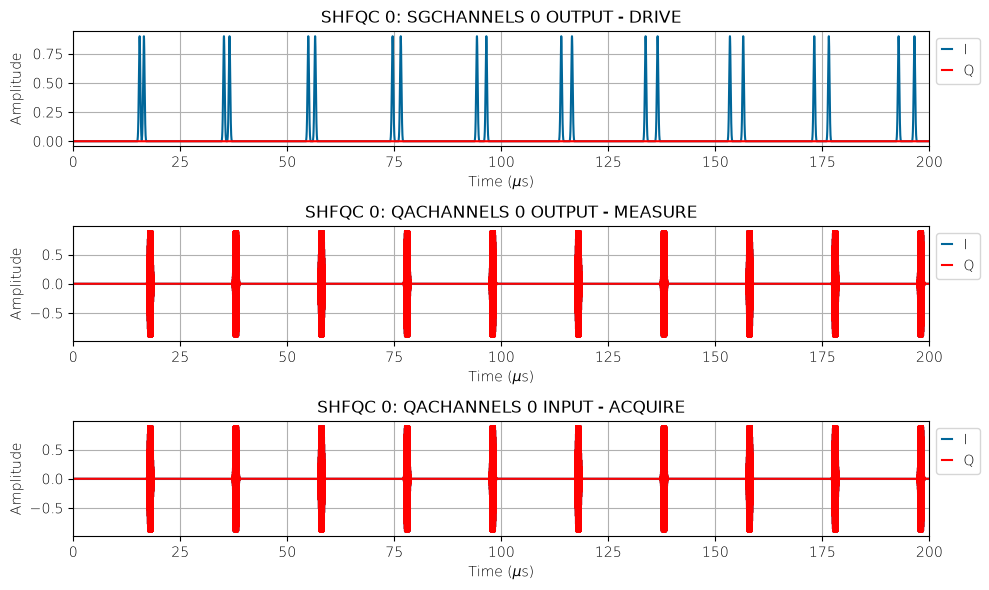

In [8]:
plot_simulation(compiled_ramsey, start_time=0, length=200e-6, plot_width=10)

### 3.3 Run, Save, and Plot Results

Finally, you'll run the experiment, save, and plot the results.

In [9]:
# run the compiled experiemnt
ramsey_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(ramsey_results, f"Results/{timestamp}_ramsey_results.json")
print(f"File saved as Results/{timestamp}_ramsey_results.json")

[2026.06.26 11:09:36.508] INFO    Starting near-time execution...
[2026.06.26 11:09:36.522] INFO    Finished near-time execution.
File saved as Results/20260626T110936_ramsey_results.json


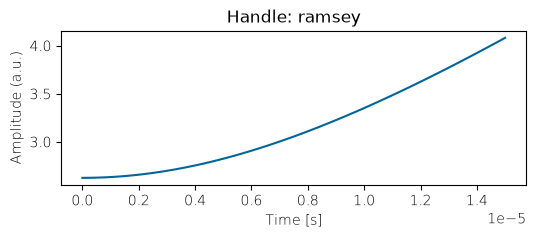

In [10]:
# plot_result_2d(ramsey_results, list(ramsey_results.acquired_results.keys())[0])
plot_results(ramsey_results)

## 4. Fitting Results

You can also fit your results. The below script fits some emulated Rabi data when running in emulation mode.

In [11]:
# get measurement data returned by the instruments
ramsey_res = ramsey_results.get_data("ramsey")

# define time axis from qubit parameters
ramsey_delay = ramsey_results.get_axis("ramsey")[0]

if use_emulation:
    # create dummy data if running in emulation mode
    ramsey_res = oscillatory_decay(
        ramsey_delay, 1e6, 0, 1 / 10e-6, amplitude=0.5, offset=0.5
    ) + 0.12 * np.random.rand(len(ramsey_delay))

# plot measurement results
fig = plt.figure()
plt.plot(ramsey_delay, ramsey_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(ramsey_delay[0], ramsey_delay[-1], 5 * len(ramsey_delay))

## fit measurement data to decaying sinusoidal oscillatio
popt, pcov = oscillatory_decay.fit(
    ramsey_delay,
    ramsey_res,
    1e6,
    0,
    2 / 1 / 10e-6,
    0.5,
    0.5,
    plot=False,
    bounds=[
        [0.01e6, -np.pi / 2, 0.1 / 1 / 10e-6, 0.2, 0.2],
        [15e6, np.pi / 2, 10 / 1 / 10e-6, 2, 2],
    ],
)
print(f"Fitted parameters: {popt}")

# plot fit results together with experimental data
plt.plot(delay_plot, oscillatory_decay(delay_plot, *popt), "-r")

Fitted parameters: [1.00018215e+06 1.48456135e-02 1.04198733e+05 5.08325114e-01
 5.63639879e-01]
